# Aerogel Filtration ML --> Step 6: Validation & Design Map

**What this notebook does:**
- Bootstrap stability: are SHAP importance rankings stable across resamples?
- Subgroup analysis: do material families show different structure-property rules?
- Physics consistency: do SHAP findings align with filtration theory?
- Design maps: filtration efficiency vs pressure drop, and QF vs efficiency


## 6.1: Imports and load all data

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from scipy import stats

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42
N_BOOTSTRAP  = 200

# ------------ Load Step 4 models ---------------
with open('step4_models.pkl', 'rb') as f:
    saved = pickle.load(f)

final_xgb_eff = saved['final_xgb_eff']
final_xgb_qf  = saved['final_xgb_qf']   # PRIMARY model for QF 
final_rf_qf   = saved['final_rf_qf']    #  robustness check
FEATURES_EFF  = saved['FEATURES_EFF']
FEATURES_QF   = saved['FEATURES_QF']
X_eff_full    = saved['X_eff_full']
X_qf_full     = saved['X_qf_full']

# Use the same transformed targets used in Step 4 and Step 5
y_eff_saved = np.asarray(saved['y_eff']).ravel()   # log_penetration
y_qf_saved  = np.asarray(saved['y_qf']).ravel()    # log_quality_factor

# ── Load Step 5 SHAP values ───────────────────────────────────────
with open('step5_shap_values.pkl', 'rb') as f:
    shap_saved = pickle.load(f)

shap_xgb_eff      = shap_saved['shap_xgb_eff']
shap_xgb_qf       = shap_saved['shap_xgb_qf']   # PRIMARY
shap_rf_qf        = shap_saved['shap_rf_qf']    # robustness check
feature_names_eff = shap_saved['feature_names_eff']
feature_names_qf  = shap_saved['feature_names_qf']

# ----------------- Load model-ready datasets -----------------------
df_eff = pd.read_csv('model_data_filtration.csv')
df_qf  = pd.read_csv('model_data_qualityfactor.csv')

# ----------------- Load ORIGINAL dataset for design maps -----------------------
# This has raw pressure drop, material family, architecture columns

df_orig = pd.read_csv('final_dataset.csv')
df_orig.dropna(how='all', inplace=True)
df_orig.reset_index(drop=True, inplace=True)

print('All data loaded.')
print(f'  Filtration model dataset:   {df_eff.shape}')
print(f'  Quality factor dataset:     {df_qf.shape}')
print(f'  Original dataset (df_orig): {df_orig.shape}')

All data loaded.
  Filtration model dataset:   (195, 60)
  Quality factor dataset:     (82, 60)
  Original dataset (df_orig): (227, 41)


## 6.2: Detect column names automatically

In [2]:
# Auto-detect the correct column names in df_orig.
# This handles cases where the column name differs slightly
# between the original file and the processed files.

def find_col(df, candidates):
    """Return the first candidate column name found in df."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

EFF_COL   = find_col(df_orig, ['filtration_efficiency (%)', 'filtration_efficiency'])
PDROP_COL = find_col(df_orig, ['pressure_drop (mmH2O/cm)', 'pressure_drop (mmH2O)',
                                'pressure_drop', 'pressure drop (mmH2O/cm)'])
QF_COL    = find_col(df_orig, ['quality_factor (mmH2O^-1)', 'quality_factor',
                                'quality_factor (mmH2O-1)'])
FAM_COL   = find_col(df_orig, ['primary_material_family', 'primary material family',
                                'material_class_std', 'material_class'])
ARCH_COL  = find_col(df_orig, ['architecture_descriptor', 'architecture descriptor',
                                'material_class_std'])

print('Column detection results:')
print(f'  Filtration efficiency : {EFF_COL}')
print(f'  Pressure drop         : {PDROP_COL}')
print(f'  Quality factor        : {QF_COL}')
print(f'  Material family       : {FAM_COL}')
print(f'  Architecture          : {ARCH_COL}')
print()

#  detect columns in the model-ready datasets
EFF_COL_MODEL  = find_col(df_eff, ['filtration_efficiency (%)', 'filtration_efficiency'])
QF_COL_MODEL   = find_col(df_qf,  ['log_quality_factor'])
FAM_COL_MODEL  = find_col(df_eff,  ['primary_material_family'])
ARCH_COL_MODEL = find_col(df_eff,  ['architecture_descriptor'])

# force numeric types on key columns in df_orig right away
for col in [EFF_COL, PDROP_COL, QF_COL]:
    if col:
        df_orig[col] = pd.to_numeric(df_orig[col], errors='coerce')

print('All key columns converted to numeric.')
print(f'  {EFF_COL}  dtype: {df_orig[EFF_COL].dtype}')
if PDROP_COL:
    print(f'  {PDROP_COL} dtype: {df_orig[PDROP_COL].dtype}')

Column detection results:
  Filtration efficiency : filtration_efficiency (%)
  Pressure drop         : pressure_drop (mmH2O/cm)
  Quality factor        : quality_factor (mmH2O^-1)
  Material family       : primary_material_family
  Architecture          : architecture_descriptor

All key columns converted to numeric.
  filtration_efficiency (%)  dtype: float64
  pressure_drop (mmH2O/cm) dtype: float64


## 6.3: Bootstrap SHAP stability: filtration efficiency

In [3]:
# Refit XGBoost on 200 bootstrap resamples and record feature rank each time.

xgb_params = {k: v for k, v in final_xgb_eff.get_params().items()
              if k not in ['n_jobs', 'verbosity', 'use_label_encoder']}


y_eff = y_eff_saved

n_samples  = len(X_eff_full)
n_features = len(FEATURES_EFF)
rng        = np.random.RandomState(RANDOM_STATE)

bootstrap_ranks_eff = np.zeros((N_BOOTSTRAP, n_features))

print(f'Running {N_BOOTSTRAP} bootstrap iterations — filtration efficiency...')

for i in range(N_BOOTSTRAP):
    idx    = rng.choice(n_samples, size=n_samples, replace=True)
    X_boot = X_eff_full[idx]
    y_boot = y_eff[idx]

    model = XGBRegressor(**xgb_params, n_jobs=-1, verbosity=0)
    model.fit(X_boot, y_boot)

    exp       = shap.TreeExplainer(model)
    shap_vals = exp.shap_values(X_eff_full)
    mean_abs  = np.abs(shap_vals).mean(axis=0)
    ranks     = n_features - np.argsort(np.argsort(mean_abs))
    bootstrap_ranks_eff[i] = ranks

    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{N_BOOTSTRAP} done')

print('Bootstrap complete — filtration efficiency.')

Running 200 bootstrap iterations — filtration efficiency...
  20/200 done
  40/200 done
  60/200 done
  80/200 done
  100/200 done
  120/200 done
  140/200 done
  160/200 done
  180/200 done
  200/200 done
Bootstrap complete — filtration efficiency.


## 6.4: Bootstrap SHAP stability: quality factor

In [4]:
# --------------- QF bootstrap now uses XGBoost (primary model for QF) --------------------

xgb_qf_params = {k: v for k, v in final_xgb_qf.get_params().items()
                 if k not in ['n_jobs', 'verbosity', 'use_label_encoder']}

y_qf          = df_qf[QF_COL_MODEL].values
n_samples_qf  = len(X_qf_full)
n_features_qf = len(FEATURES_QF)

bootstrap_ranks_qf = np.zeros((N_BOOTSTRAP, n_features_qf))

print(f'Running {N_BOOTSTRAP} bootstrap iterations — quality factor (XGBoost)...')

for i in range(N_BOOTSTRAP):
    idx    = rng.choice(n_samples_qf, size=n_samples_qf, replace=True)
    X_boot = X_qf_full[idx]
    y_boot = y_qf[idx]

    model = XGBRegressor(**xgb_qf_params, n_jobs=-1, verbosity=0)
    model.fit(X_boot, y_boot)

    exp       = shap.TreeExplainer(model)
    shap_vals = exp.shap_values(X_qf_full)
    mean_abs  = np.abs(shap_vals).mean(axis=0)
    ranks     = n_features_qf - np.argsort(np.argsort(mean_abs))
    bootstrap_ranks_qf[i] = ranks

    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{N_BOOTSTRAP} done')

print('Bootstrap complete — quality factor.')


Running 200 bootstrap iterations — quality factor (XGBoost)...
  20/200 done
  40/200 done
  60/200 done
  80/200 done
  100/200 done
  120/200 done
  140/200 done
  160/200 done
  180/200 done
  200/200 done
Bootstrap complete — quality factor.


## 6.5: Rank stability plots

In [5]:
def plot_rank_stability(bootstrap_ranks, feature_names, shap_values,
                        title, filename, top_n=10):
    orig_importance = np.abs(shap_values).mean(axis=0)
    orig_rank_order = np.argsort(orig_importance)[::-1][:top_n]
    top_features    = [feature_names[i] for i in orig_rank_order]
    rank_data       = [bootstrap_ranks[:, i] for i in orig_rank_order]

    fig, ax = plt.subplots(figsize=(11, 5))

    colors = []
    for data in rank_data:
        iqr = np.percentile(data, 75) - np.percentile(data, 25)
        colors.append('#2980B9' if iqr <= 3 else '#E67E22' if iqr <= 6 else '#922B21')

    bp = ax.boxplot(
        rank_data, vert=True, patch_artist=True, widths=0.5,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(
            marker='o',
            markersize=3,
            markerfacecolor='gray',
            markeredgecolor='none',
            alpha=0.3
        )
    )

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(range(1, top_n + 1))
    ax.set_xticklabels([f.replace(' ', '\n') for f in top_features], fontsize=7)
    ax.set_ylabel('Rank across bootstrap samples\n(lower = more important)')
    ax.set_title(title)
    ax.invert_yaxis()

    legend_elements = [
        mpatches.Patch(facecolor='#2980B9', alpha=0.7, label='Stable (IQR ≤ 3)'),
        mpatches.Patch(facecolor='#E67E22', alpha=0.7, label='Moderate (IQR ≤ 6)'),
        mpatches.Patch(facecolor='#922B21', alpha=0.7, label='Unstable (IQR > 6)'),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()   
    print(f'Saved: {filename}')
    print(f'\nStability summary:')
    print(f'{"Feature":<45} {"Median rank":>12} {"IQR":>6} {"Status"}')
    print('-' * 75)
    for feat, data in zip(top_features, rank_data):
        med  = np.median(data)
        iqr  = np.percentile(data, 75) - np.percentile(data, 25)
        stab = 'Stable' if iqr <= 3 else 'Moderate' if iqr <= 6 else 'Unstable'
        print(f'{feat:<45} {med:>12.1f} {iqr:>6.1f}   {stab}')

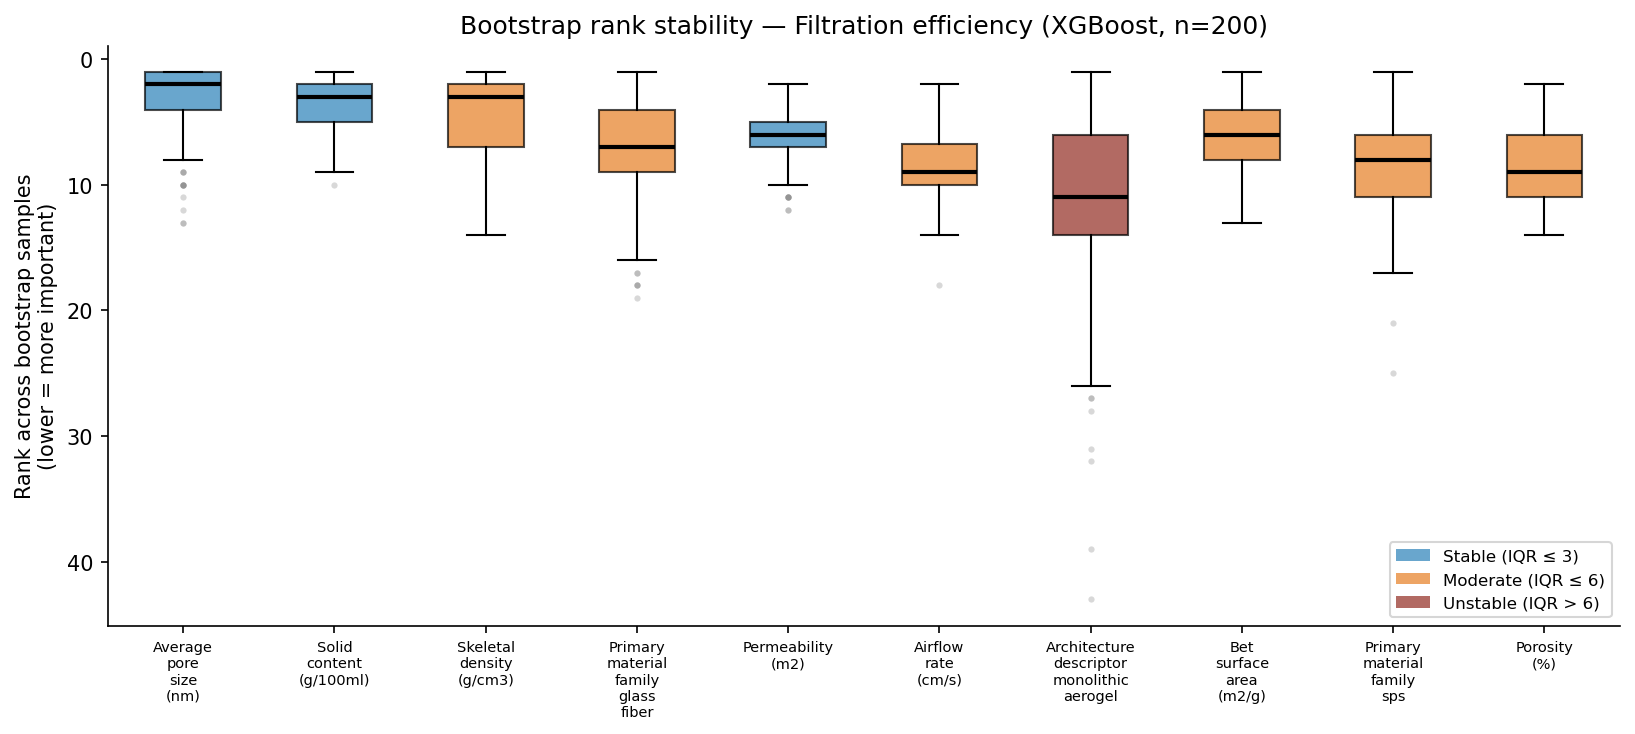

Saved: bootstrap_stability_filtration.png

Stability summary:
Feature                                        Median rank    IQR Status
---------------------------------------------------------------------------
Average pore size (nm)                                 2.0    3.0   Stable
Solid content (g/100ml)                                3.0    3.0   Stable
Skeletal density (g/cm3)                               3.0    5.0   Moderate
Primary material family glass fiber                    7.0    5.0   Moderate
Permeability (m2)                                      6.0    2.0   Stable
Airflow rate (cm/s)                                    9.0    3.2   Moderate
Architecture descriptor monolithic aerogel            11.0    8.0   Unstable
Bet surface area (m2/g)                                6.0    4.0   Moderate
Primary material family sps                            8.0    5.0   Moderate
Porosity (%)                                           9.0    5.0   Moderate


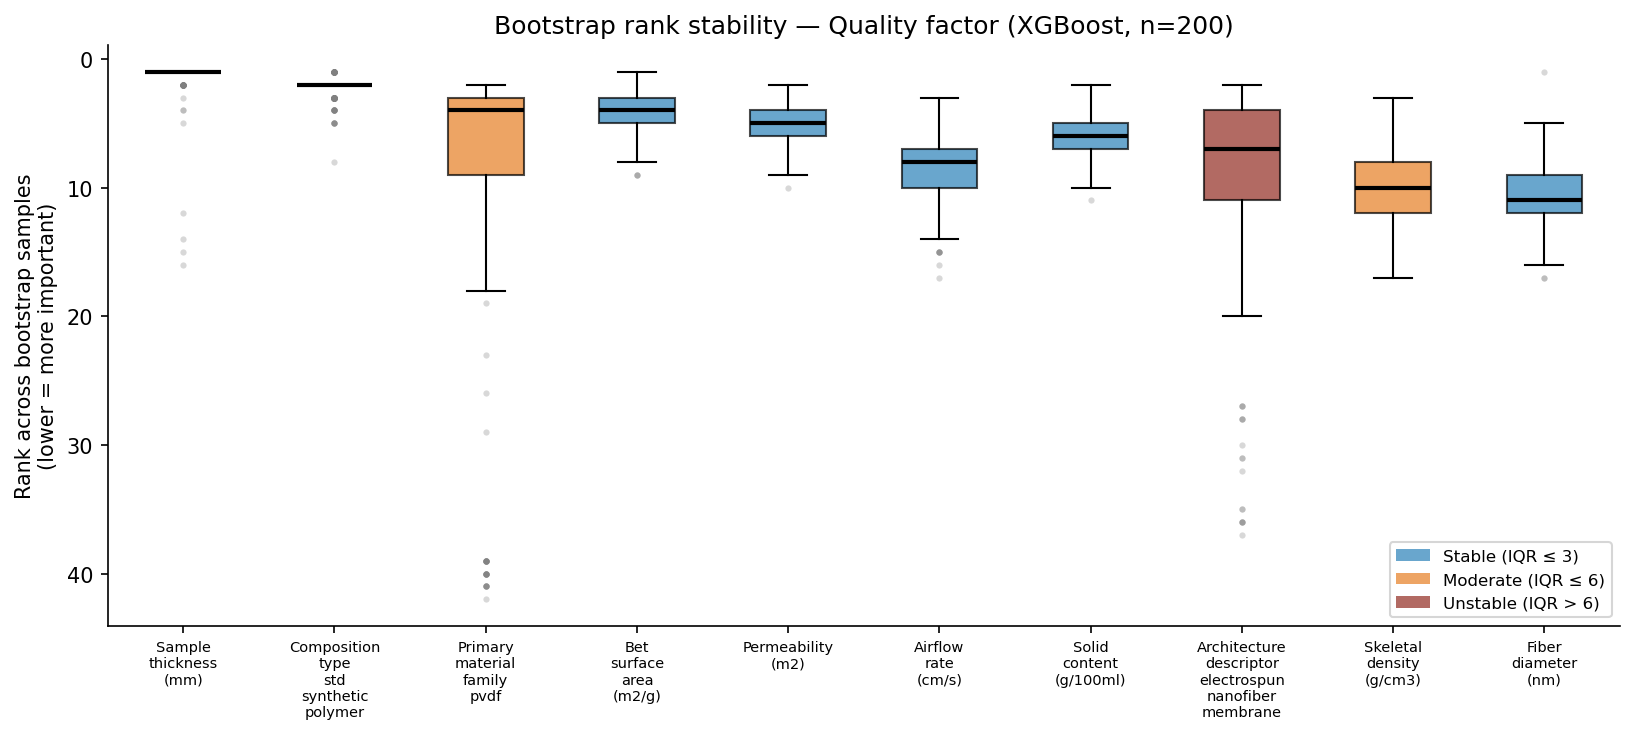

Saved: bootstrap_stability_qualityfactor.png

Stability summary:
Feature                                        Median rank    IQR Status
---------------------------------------------------------------------------
Sample thickness (mm)                                  1.0    0.0   Stable
Composition type std synthetic polymer                 2.0    0.0   Stable
Primary material family pvdf                           4.0    6.0   Moderate
Bet surface area (m2/g)                                4.0    2.0   Stable
Permeability (m2)                                      5.0    2.0   Stable
Airflow rate (cm/s)                                    8.0    3.0   Stable
Solid content (g/100ml)                                6.0    2.0   Stable
Architecture descriptor electrospun nanofiber membrane          7.0    7.0   Unstable
Skeletal density (g/cm3)                              10.0    4.0   Moderate
Fiber diameter (nm)                                   11.0    3.0   Stable


In [6]:
plot_rank_stability(
    bootstrap_ranks_eff, feature_names_eff, shap_xgb_eff,
    f'Bootstrap rank stability — Filtration efficiency (XGBoost, n={N_BOOTSTRAP})',
    'bootstrap_stability_filtration.png'
)

plot_rank_stability(
    bootstrap_ranks_qf, feature_names_qf, shap_xgb_qf,
    f'Bootstrap rank stability — Quality factor (XGBoost, n={N_BOOTSTRAP})',
    'bootstrap_stability_qualityfactor.png'
)

## 6.6: Subgroup analysis

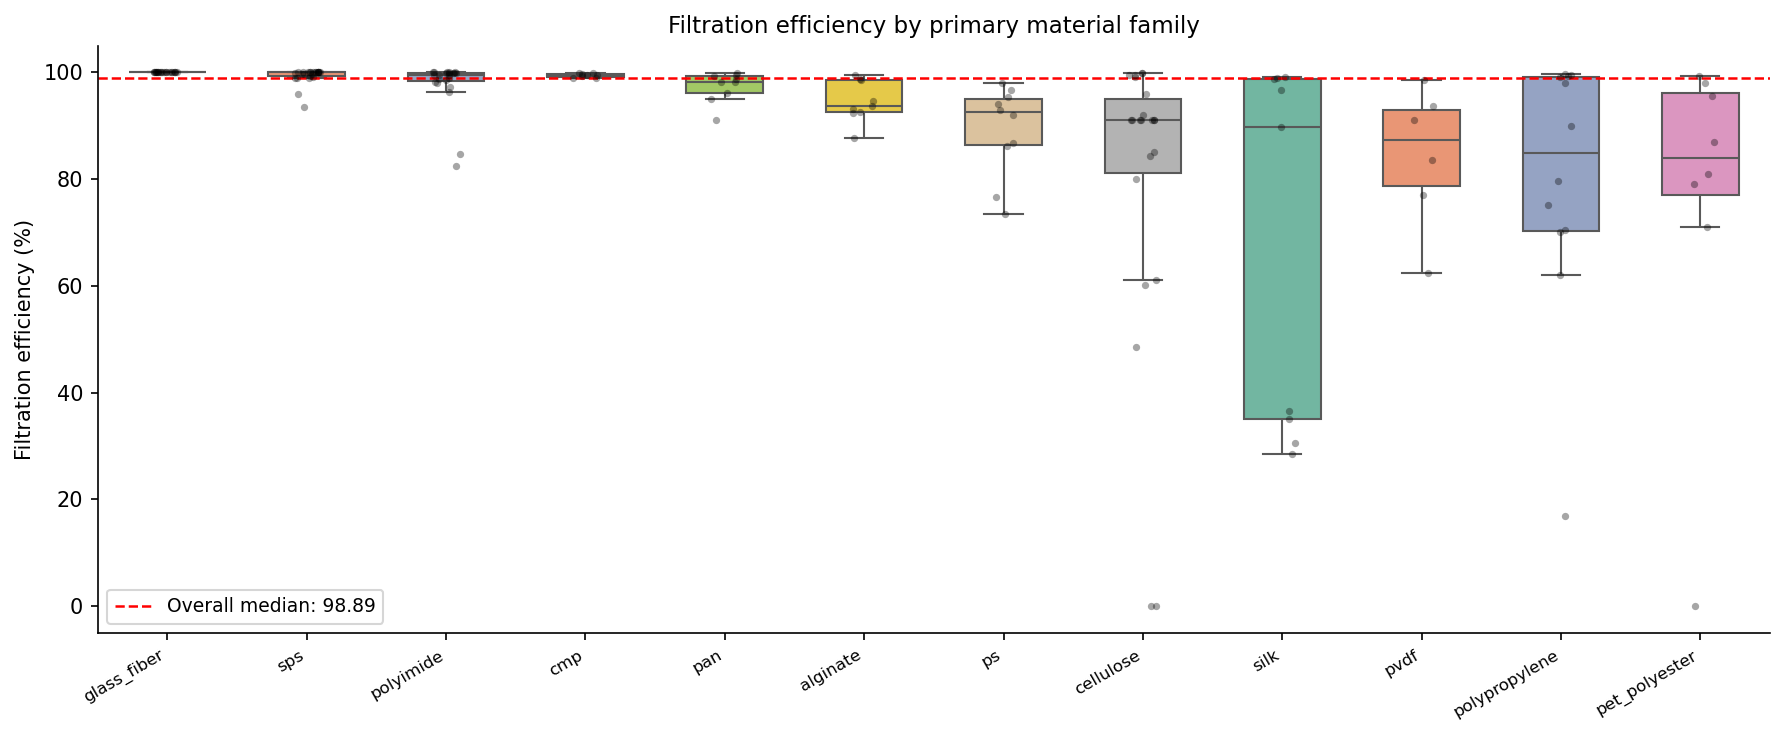

Saved: subgroup_family_filtration.png

Group statistics (Filtration efficiency (%)):
Group                                  n   Median      IQR
----------------------------------------------------------
glass_fiber                           21   100.00     0.02
sps                                   25    99.99     0.64
polyimide                             22    99.53     1.63
cmp                                    8    99.45     0.57
pan                                    9    98.11     3.15
alginate                               9    93.63     6.12
ps                                    10    92.50     8.63
cellulose                             22    91.00    13.90
silk                                   9    89.70    63.70
pvdf                                   6    87.38    14.32
polypropylene                         12    84.85    28.85
pet_polyester                          8    84.00    19.16


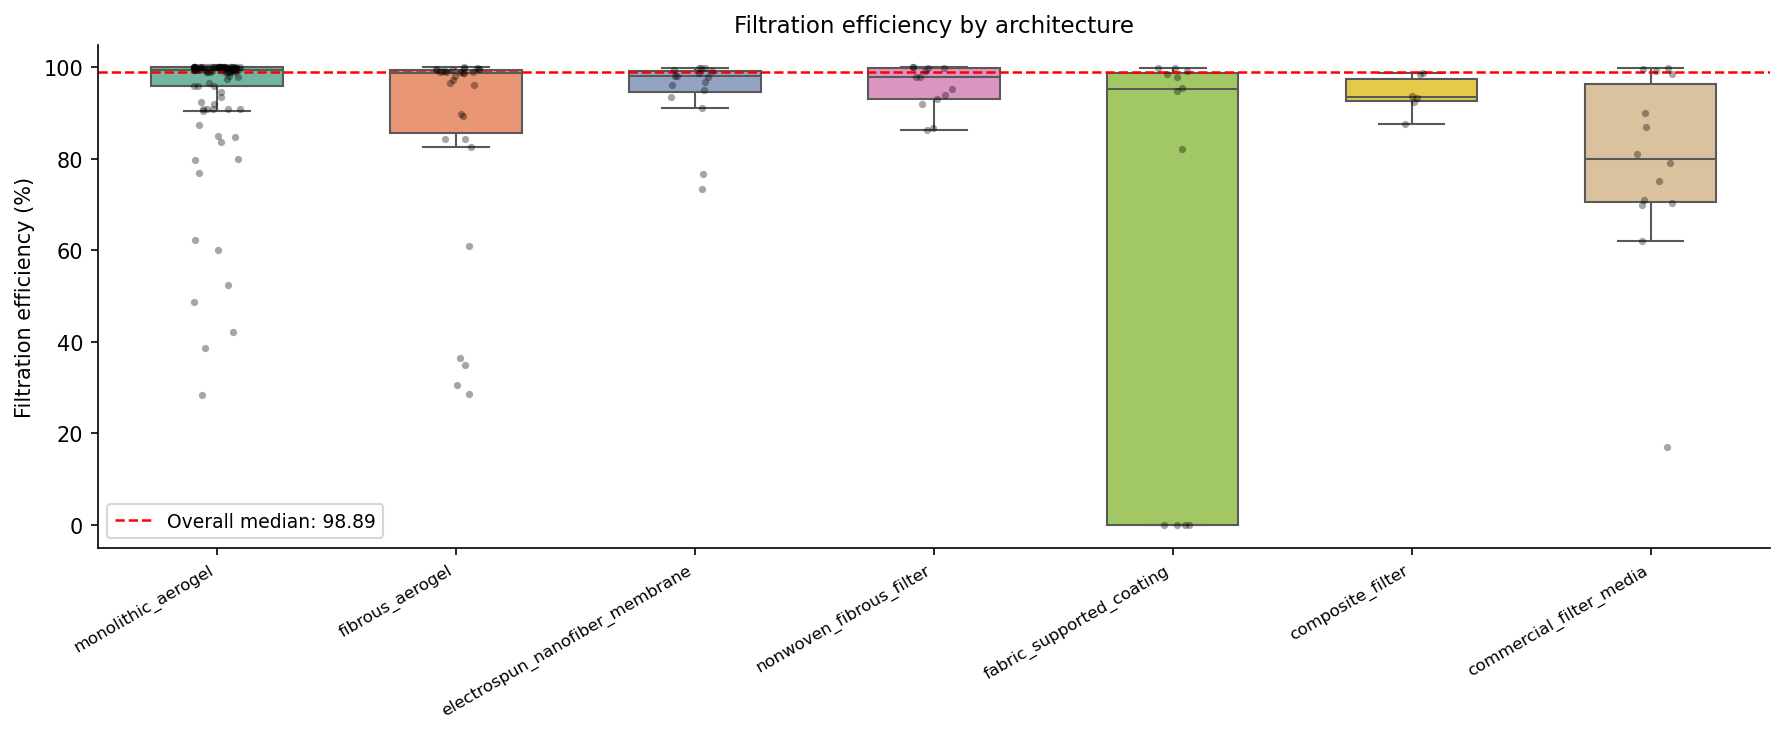

Saved: subgroup_architecture_filtration.png

Group statistics (Filtration efficiency (%)):
Group                                  n   Median      IQR
----------------------------------------------------------
monolithic_aerogel                    98    99.50     4.10
fibrous_aerogel                       30    98.70    13.74
electrospun_nanofiber_membrane        16    98.06     4.61
nonwoven_fibrous_filter               13    97.99     6.90
fabric_supported_coating              12    95.22    98.77
composite_filter                       6    93.41     4.76
commercial_filter_media               14    80.00    25.86


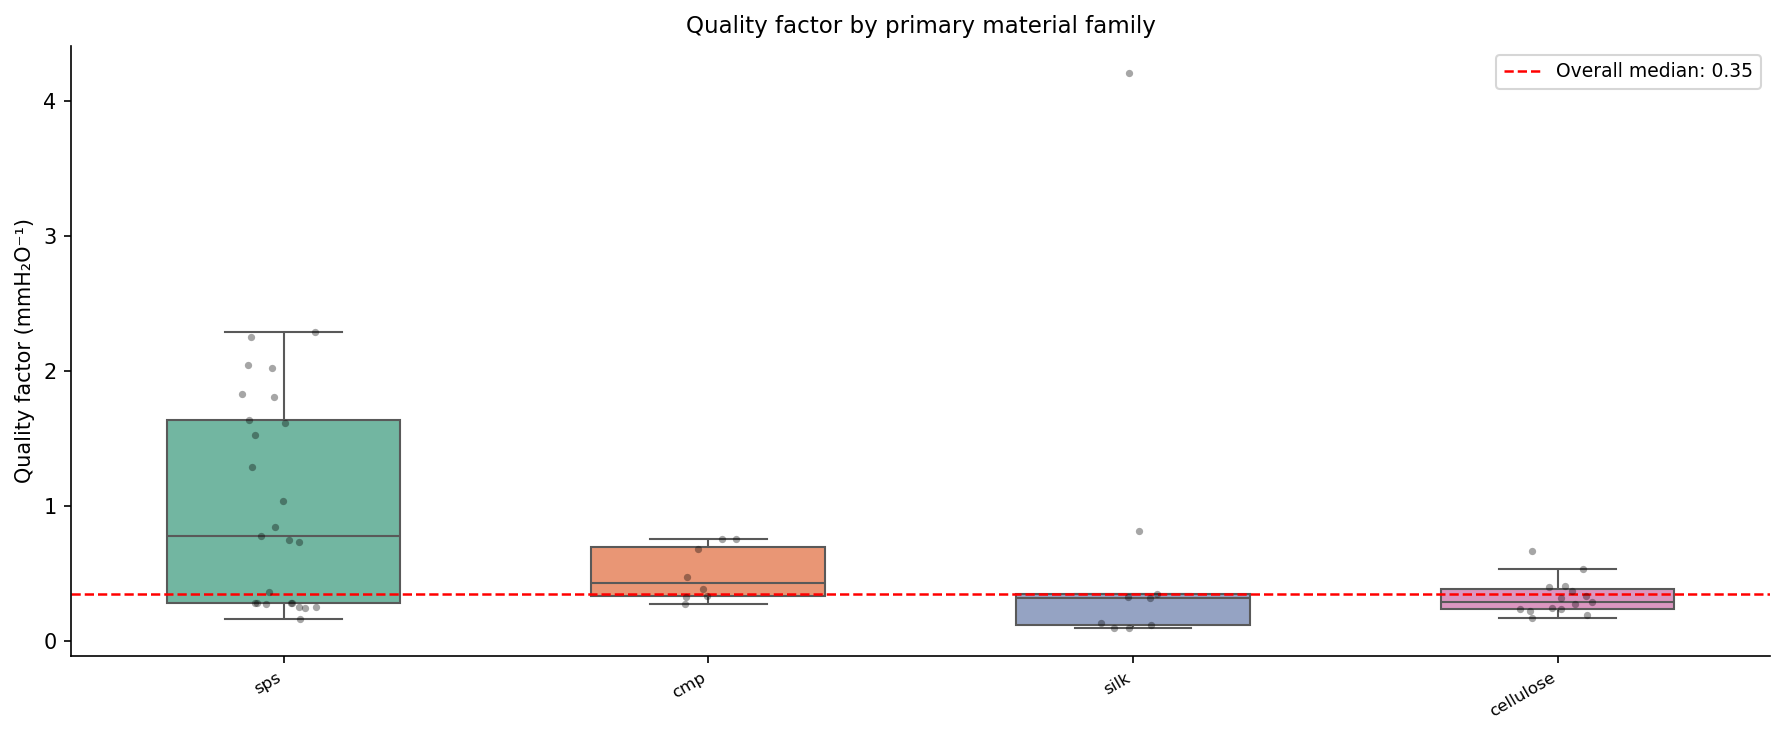

Saved: subgroup_family_qf.png

Group statistics (Quality factor (mmH₂O⁻¹)):
Group                                  n   Median      IQR
----------------------------------------------------------
sps                                   25     0.77     1.36
cmp                                    8     0.43     0.37
silk                                   9     0.32     0.23
cellulose                             15     0.28     0.15


In [7]:
def subgroup_boxplot(df, group_col, target_col, target_label,
                     title, filename, min_n=6):
    if group_col is None or group_col not in df.columns:
        print(f'Column {group_col} not found — skipping.')
        return
    data = df[[group_col, target_col]].copy()
    data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
    data = data.dropna()
    counts = data[group_col].value_counts()
    valid  = counts[counts >= min_n].index
    data   = data[data[group_col].isin(valid)]
    if data.empty:
        print(f'No groups with n>={min_n}. Nothing to plot.')
        return
    order = (data.groupby(group_col)[target_col]
               .median()
               .sort_values(ascending=False)
               .index)
    fig, ax = plt.subplots(figsize=(12, 5))
    palette = sns.color_palette('Set2', len(order))

    # flierprops=dict(marker='') suppresses the default boxplot outlier circles.
    # stripplot below already shows every individual data point,
    # so the outlier circles are redundant and cause a partial-overlap artefact.
    
    sns.boxplot(data=data, x=group_col, y=target_col, order=order,
                palette=palette, width=0.55, ax=ax,
                flierprops=dict(marker='', markersize=0))

    sns.stripplot(data=data, x=group_col, y=target_col, order=order,
                  color='black', alpha=0.35, size=3.5, jitter=True, ax=ax)

    overall_med = data[target_col].median()
    ax.axhline(overall_med, color='red', linestyle='--', linewidth=1.2,
               label=f'Overall median: {overall_med:.2f}')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(target_label)
    ax.legend(fontsize=9)
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')
    print(f'\nGroup statistics ({target_label}):')
    print(f'{"Group":<35} {"n":>4} {"Median":>8} {"IQR":>8}')
    print('-' * 58)
    for grp in order:
        vals = data[data[group_col] == grp][target_col]
        iqr  = vals.quantile(0.75) - vals.quantile(0.25)
        print(f'{str(grp):<35} {len(vals):>4} {vals.median():>8.2f} {iqr:>8.2f}')


# -------- Filtration efficiency by material family -------------------
subgroup_boxplot(
    df_orig, FAM_COL, EFF_COL,
    'Filtration efficiency (%)',
    'Filtration efficiency by primary material family',
    'subgroup_family_filtration.png'
)

# ------ Filtration efficiency by architecture ------------------
subgroup_boxplot(
    df_orig, ARCH_COL, EFF_COL,
    'Filtration efficiency (%)',
    'Filtration efficiency by architecture',
    'subgroup_architecture_filtration.png'
)

# ------- Quality factor by material family -----------------
subgroup_boxplot(
    df_orig, FAM_COL, QF_COL,
    'Quality factor (mmH\u2082O\u207B\u00B9)',
    'Quality factor by primary material family',
    'subgroup_family_qf.png'
)

## 6.7: Physics consistency check

In [8]:
# Test whether SHAP-identified relationships match classical filtration theory.
# Uses Spearman correlation

def find_col_either(df1, df2, candidates):
    """Find column in either df1 or df2."""
    for c in candidates:
        if c in df1.columns: return df1, c
        if c in df2.columns: return df2, c
    return None, None

print('PHYSICS CONSISTENCY CHECKS')
print('=' * 70)
print(f'{"Hypothesis":<45} {"r_s":>6} {"p-value":>10} {"Expected":>10} {"OK?"}')
print('-' * 70)

checks = [
    ('Smaller pore size → higher efficiency',
     ['average_pore_size (nm)', 'log_average_pore_size (nm)'],
     EFF_COL, df_orig, 'negative'),
    ('Lower porosity → higher efficiency',
     ['porosity (%)', 'log_porosity (%)'],
     EFF_COL, df_orig, 'negative'),
    ('Higher BET → higher efficiency',
     ['bet_surface_area (m2/g)', 'log_bet_surface_area (m2/g)'],
     EFF_COL, df_orig, 'positive'),
    ('Thinner sample → higher QF',
     ['sample_thickness (mm)', 'log_sample_thickness (mm)'],
     QF_COL, df_orig, 'negative'),
    ('Higher permeability → higher QF',
     ['permeability (m2)', 'log_permeability (m2)'],
     QF_COL, df_orig, 'positive'),
    ('Lower airflow rate → higher efficiency',
     ['airflow_rate (cm/s)', 'log_airflow_rate (cm/s)'],
     EFF_COL, df_orig, 'negative'),
    ('Smaller fiber diameter → higher efficiency',
     ['fiber_diameter (nm)', 'log_fiber_diameter (nm)'],
     EFF_COL, df_orig, 'negative'),
]

for hypothesis, feat_candidates, target_col, df, expected in checks:
    if target_col is None:
        print(f'{hypothesis:<45}  TARGET NOT FOUND')
        continue

    feat_col = None
    for c in feat_candidates:
        if c in df.columns:
            feat_col = c
            break

    if feat_col is None:
        print(f'{hypothesis:<45}  FEATURE NOT FOUND')
        continue

    pair = df[[feat_col, target_col]].copy()
    pair[feat_col]   = pd.to_numeric(pair[feat_col],   errors='coerce')
    pair[target_col] = pd.to_numeric(pair[target_col], errors='coerce')
    pair = pair.dropna()

    if len(pair) < 10:
        print(f'{hypothesis:<45}  TOO FEW SAMPLES (n={len(pair)})')
        continue

    rs, pval = stats.spearmanr(pair[feat_col], pair[target_col])
    direction  = 'negative' if rs < 0 else 'positive'
    consistent = direction == expected
    sig  = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    ok   = 'YES ✓' if consistent else 'NO ✗'
    print(f'{hypothesis:<45} {rs:>6.3f} {pval:>8.4f}{sig:>3}   {expected:>10}   {ok}')

print()
print('ns = not significant, *p<0.05, **p<0.01, ***p<0.001')

PHYSICS CONSISTENCY CHECKS
Hypothesis                                       r_s    p-value   Expected OK?
----------------------------------------------------------------------
Smaller pore size → higher efficiency         -0.300   0.0088 **     negative   YES ✓
Lower porosity → higher efficiency            -0.031   0.7849 ns     negative   YES ✓
Higher BET → higher efficiency                 0.357   0.0019 **     positive   YES ✓
Thinner sample → higher QF                    -0.291   0.0080 **     negative   YES ✓
Higher permeability → higher QF                0.773   0.0000***     positive   YES ✓
Lower airflow rate → higher efficiency        -0.106   0.1773 ns     negative   YES ✓
Smaller fiber diameter → higher efficiency    -0.076   0.5295 ns     negative   YES ✓

ns = not significant, *p<0.05, **p<0.01, ***p<0.001


## 6.8: Design map: filtration efficiency vs pressure drop

In [9]:
# Compute Pareto front: maximise efficiency, minimise pressure drop

def pareto_front(eff_series, pdrop_series):
    """Return boolean mask of Pareto-optimal samples."""
    eff   = eff_series.values.astype(float)
    pdrop = pdrop_series.values.astype(float)
    n     = len(eff)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if is_pareto[i]:
            dominated = (
                (eff   >= eff[i])   &
                (pdrop <= pdrop[i]) &
                ((eff > eff[i]) | (pdrop < pdrop[i]))
            )
            dominated[i] = False
            if dominated.any():
                is_pareto[i] = False
    return is_pareto


if PDROP_COL is None:
    print('Pressure drop column not found in final_dataset.csv.')
    print('Available columns:', list(df_orig.columns))
else:
    # Build design dataset: all numeric, no NaN in key columns
    cols_needed = [EFF_COL, PDROP_COL]
    if FAM_COL:  cols_needed.append(FAM_COL)

    design_data = df_orig[cols_needed].copy()
    design_data[EFF_COL]   = pd.to_numeric(design_data[EFF_COL],   errors='coerce')
    design_data[PDROP_COL] = pd.to_numeric(design_data[PDROP_COL], errors='coerce')
    design_data = design_data.dropna(subset=[EFF_COL, PDROP_COL]).reset_index(drop=True)

    print(f'Samples with efficiency + pressure drop: {len(design_data)}')

    # Pareto front
    pareto_mask = pareto_front(design_data[EFF_COL], design_data[PDROP_COL])
    print(f'Pareto-optimal samples: {pareto_mask.sum()}')

    if FAM_COL and FAM_COL in design_data.columns:
        print('\nPareto front samples:')
        print(design_data[pareto_mask][[FAM_COL, EFF_COL, PDROP_COL]]
              .sort_values(EFF_COL, ascending=False).to_string())

Samples with efficiency + pressure drop: 95
Pareto-optimal samples: 4

Pareto front samples:
   primary_material_family  filtration_efficiency (%)  pressure_drop (mmH2O/cm)
12                     sps                    99.9980                     12.60
64               polyimide                    99.9375                      6.42
60                     pan                    99.2700                      3.36
49                    silk                    99.1000                      2.24


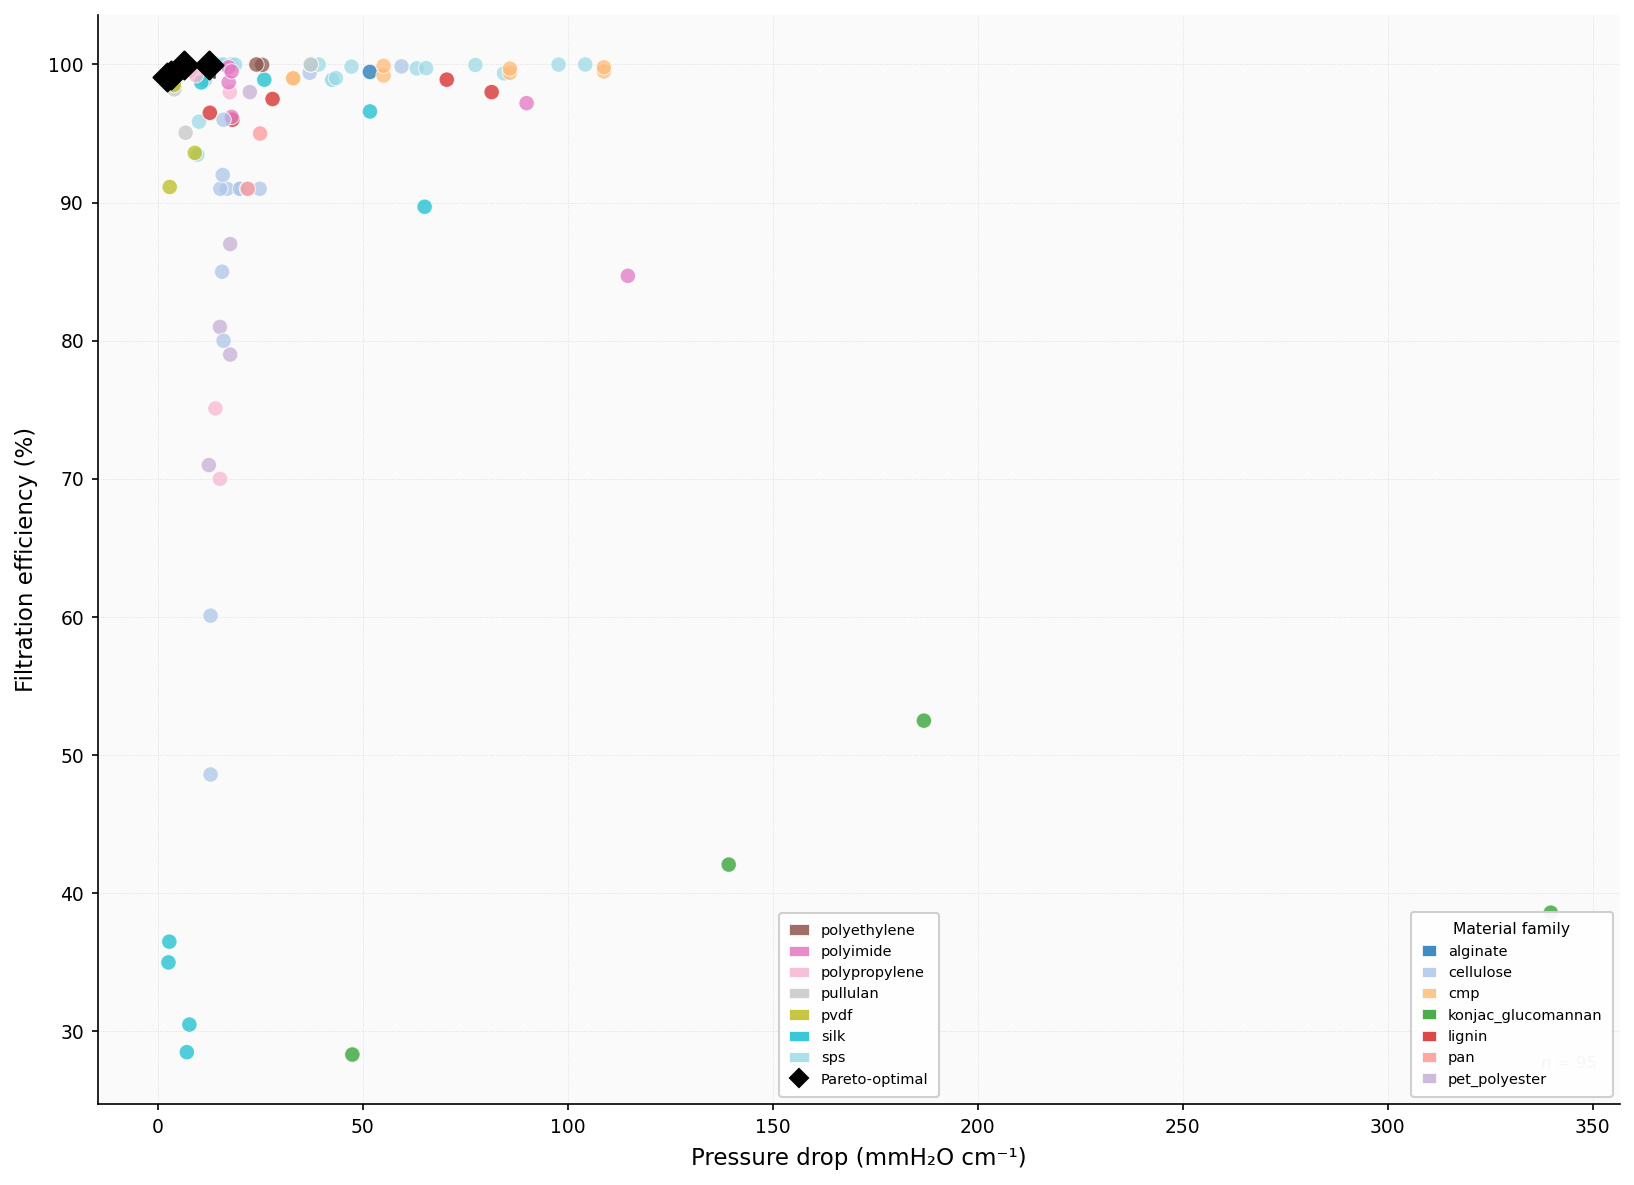

Saved: design_map.png / design_map.pdf


In [10]:
if PDROP_COL and not design_data.empty:

    # ---- Colour by material family -----------------------
    
    if FAM_COL and FAM_COL in design_data.columns:
        families        = design_data[FAM_COL].fillna('unknown').astype(str)
        unique_families = sorted(families.unique())
        cmap            = plt.cm.tab20(np.linspace(0, 1, max(len(unique_families), 2)))
        palette         = dict(zip(unique_families, cmap))
        dot_colors      = [palette[f] for f in families]
        use_palette     = True
    else:
        dot_colors  = 'steelblue'
        use_palette = False

    plt.rcParams.update({
        'font.size':        9,
        'axes.linewidth':   0.8,
        'axes.spines.top':  False,
        'axes.spines.right':False,
        'xtick.direction':  'out',
        'ytick.direction':  'out',
        'xtick.major.size': 3,
        'ytick.major.size': 3,
        'pdf.fonttype':     42,
        'ps.fonttype':      42,
    })

    fig, ax = plt.subplots(figsize=(11, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#FAFAFA')
    ax.grid(True, linestyle=':', linewidth=0.4, color='#CCCCCC', alpha=0.7, zorder=0)

    # ------- All samples --------------------------
    ax.scatter(
        design_data[PDROP_COL], design_data[EFF_COL],
        c=dot_colors, alpha=0.75, s=55,
        edgecolors='white', linewidths=0.5, zorder=3
    )

    # ---------- Pareto front markers ----------------
    pf = design_data[pareto_mask].sort_values(PDROP_COL).reset_index(drop=True)
    ax.scatter(
        pf[PDROP_COL], pf[EFF_COL],
        c='black', s=90, zorder=5, marker='D', label='Pareto-optimal'
    )

    # -------- Pareto step line ------------------
    pf_pdrop = pf[PDROP_COL].astype(float).tolist()
    pf_eff   = pf[EFF_COL].astype(float).tolist()
    ax.step(
        pf_pdrop + [max(pf_pdrop) * 1.1],
        pf_eff   + [min(pf_eff)],
        where='post', color='black', linewidth=1.2,
        alpha=0.7, zorder=4
    )

    # --------- Legends ---------------------
    if use_palette:
        family_handles = [
            mpatches.Patch(facecolor=palette[f], label=f, alpha=0.85,
                           edgecolor='white', linewidth=0.4)
            for f in unique_families
        ]
        mid  = len(family_handles) // 2
        leg1 = ax.legend(
            handles=family_handles[:mid],
            fontsize=7, loc='lower right',
            title='Material family', title_fontsize=7.5,
            framealpha=0.93, edgecolor='#CCCCCC',
            handlelength=1.0, borderpad=0.7,
        )
        ax.add_artist(leg1)

        pareto_handle = plt.Line2D(
            [0], [0], marker='D', color='w',
            markerfacecolor='black', markeredgecolor='black',
            markersize=6, label='Pareto-optimal'
        )
        ax.legend(
            handles=family_handles[mid:] + [pareto_handle],
            fontsize=7, loc='lower center',
            framealpha=0.93, edgecolor='#CCCCCC',
            handlelength=1.4, borderpad=0.7,
        )
    else:
        ax.legend(fontsize=9)

    # ------ Axes ---------------------
    ax.set_xlabel('Pressure drop (mmH₂O cm⁻¹)', fontsize=11, labelpad=5)
    ax.set_ylabel('Filtration efficiency (%)', fontsize=11, labelpad=5)
    ax.text(0.985, 0.03, f'n = {len(design_data)}',
            transform=ax.transAxes, fontsize=8,
            color='#888888', ha='right', va='bottom')

    plt.tight_layout(pad=1.2)
    plt.savefig('design_map.png', dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig('design_map.pdf', bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved: design_map.png / design_map.pdf')

## 6.9: Design map: quality factor vs filtration efficiency

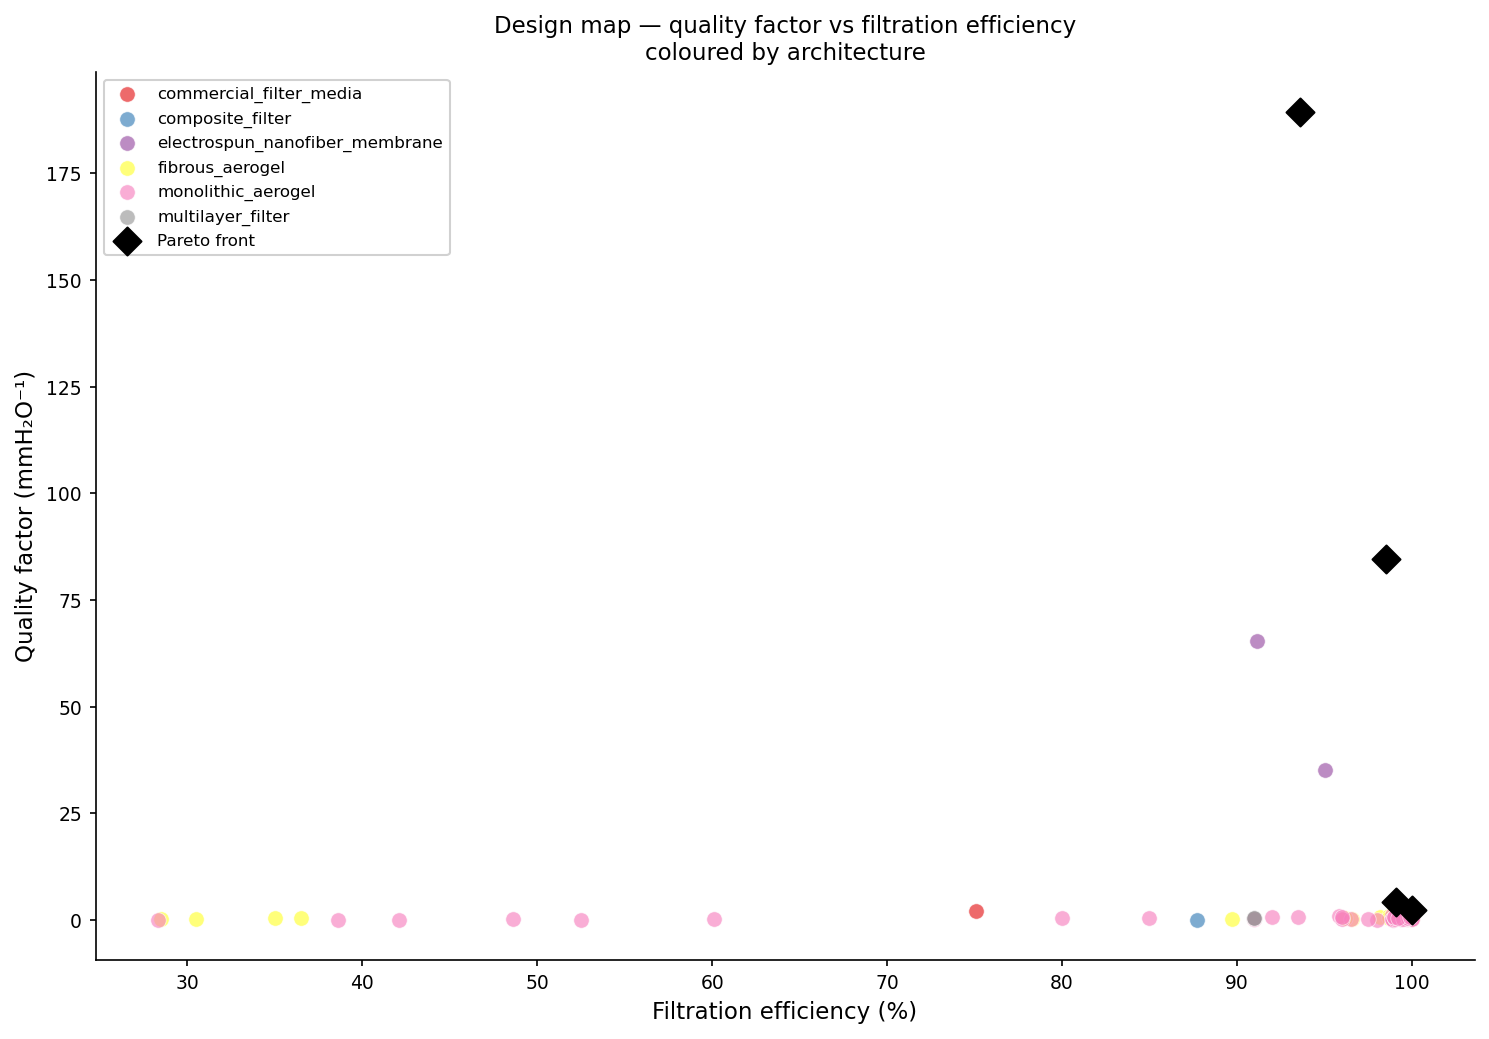

Saved: design_map_qf.png
Pareto-optimal samples: 4


In [11]:
if QF_COL and EFF_COL:

    cols_qf = [EFF_COL, QF_COL]
    if ARCH_COL: cols_qf.append(ARCH_COL)

    qf_design = df_orig[cols_qf].copy()
    qf_design[EFF_COL] = pd.to_numeric(qf_design[EFF_COL], errors='coerce')
    qf_design[QF_COL]  = pd.to_numeric(qf_design[QF_COL],  errors='coerce')
    qf_design = qf_design.dropna(subset=[EFF_COL, QF_COL]).reset_index(drop=True)

    if ARCH_COL and ARCH_COL in qf_design.columns:
        qf_design[ARCH_COL] = qf_design[ARCH_COL].fillna('unknown').astype(str)
        unique_arch  = sorted(qf_design[ARCH_COL].unique())
        arch_palette = dict(zip(unique_arch,
                                plt.cm.Set1(np.linspace(0, 1, max(len(unique_arch), 2)))))
        use_arch = True
    else:
        use_arch = False

    # Pareto front: maximise BOTH efficiency and QF
    n = len(qf_design)
    qf_pareto = np.ones(n, dtype=bool)
    eff_vals  = qf_design[EFF_COL].astype(float).values
    qf_vals   = qf_design[QF_COL].astype(float).values
    for i in range(n):
        dominated = (
            (eff_vals >= eff_vals[i]) & (qf_vals >= qf_vals[i]) &
            ((eff_vals > eff_vals[i]) | (qf_vals > qf_vals[i]))
        )
        dominated[i] = False
        if dominated.any():
            qf_pareto[i] = False

    fig, ax = plt.subplots(figsize=(10, 7))

    if use_arch:
        for arch in unique_arch:
            mask = qf_design[ARCH_COL] == arch
            ax.scatter(
                qf_design.loc[mask, EFF_COL],
                qf_design.loc[mask, QF_COL],
                color=arch_palette[arch], alpha=0.65, s=55,
                edgecolors='white', linewidths=0.4, label=arch, zorder=3
            )
    else:
        ax.scatter(qf_design[EFF_COL], qf_design[QF_COL],
                   color='steelblue', alpha=0.65, s=55, zorder=3)

    # Pareto front
    pf2 = qf_design[qf_pareto]
    ax.scatter(pf2[EFF_COL], pf2[QF_COL],
               c='black', s=90, marker='D', zorder=5, label='Pareto front')

    ax.set_xlabel('Filtration efficiency (%)', fontsize=11)
    ax.set_ylabel('Quality factor (mmH\u2082O\u207b\u00b9)', fontsize=11)
    ax.set_title(
        'Design map \u2014 quality factor vs filtration efficiency\n'
        'coloured by architecture', fontsize=11
    )
    ax.legend(fontsize=8, loc='upper left', framealpha=0.9)

    plt.tight_layout()
    plt.savefig('design_map_qf.png', bbox_inches='tight')
    plt.show()
    print('Saved: design_map_qf.png')
    print(f'Pareto-optimal samples: {qf_pareto.sum()}')

## 6.10: Save and summarize

In [12]:
with open('step6_bootstrap.pkl', 'wb') as f:
    pickle.dump({
        'bootstrap_ranks_eff': bootstrap_ranks_eff,
        'bootstrap_ranks_qf':  bootstrap_ranks_qf,
        'feature_names_eff':   feature_names_eff,
        'feature_names_qf':    feature_names_qf,
        'N_BOOTSTRAP':         N_BOOTSTRAP,
    }, f)

print('Step 6 complete. Files saved:')
print('  step6_bootstrap.pkl')
print('  bootstrap_stability_filtration.png')
print('  bootstrap_stability_qualityfactor.png')
print('  subgroup_family_filtration.png')
print('  subgroup_architecture_filtration.png')
print('  subgroup_family_qf.png')
print('  design_map.png')
print('  design_map_qf.png')
print()
print('Full ML pipeline complete.')

Step 6 complete. Files saved:
  step6_bootstrap.pkl
  bootstrap_stability_filtration.png
  bootstrap_stability_qualityfactor.png
  subgroup_family_filtration.png
  subgroup_architecture_filtration.png
  subgroup_family_qf.png
  design_map.png
  design_map_qf.png

Full ML pipeline complete.


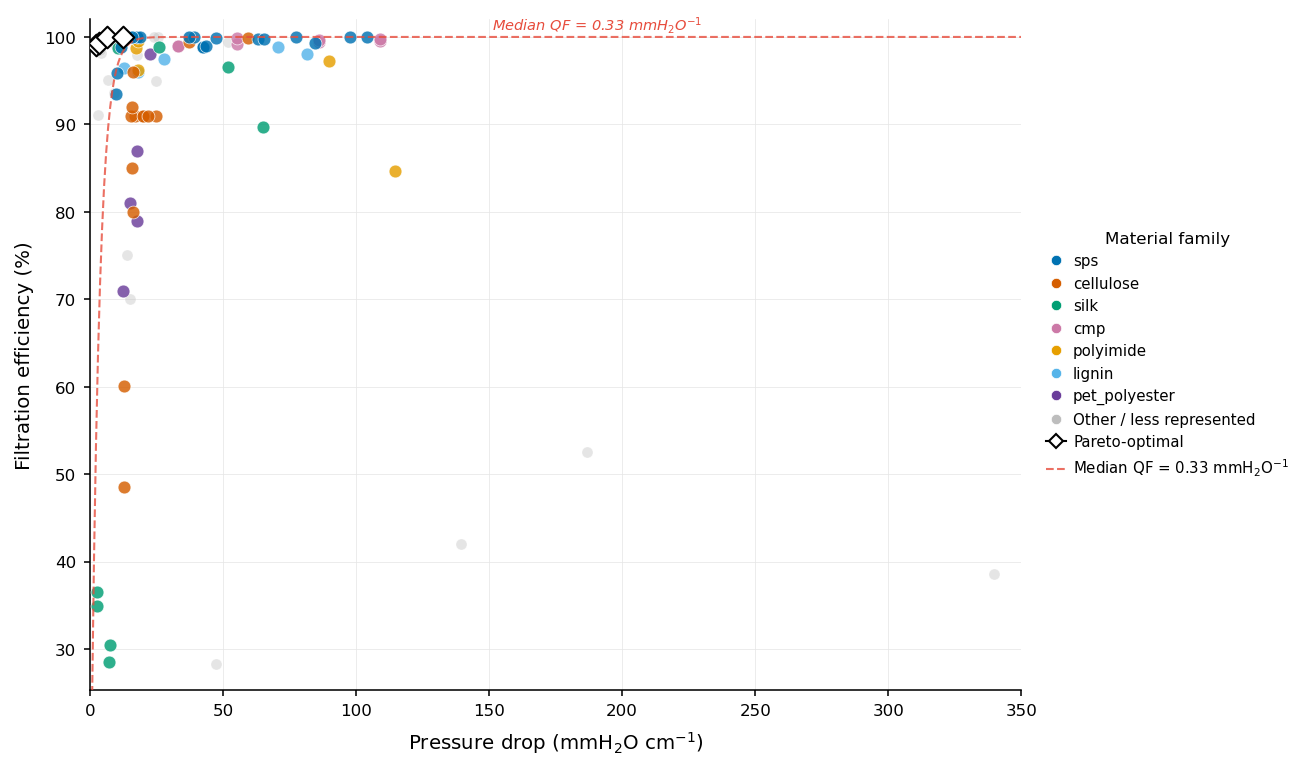

Saved: design_map_journal.png / design_map_journal.pdf


In [13]:
#better figure for design map

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from textwrap import fill

if PDROP_COL and not design_data.empty:

    plot_df = design_data.copy()
    plot_df[PDROP_COL] = pd.to_numeric(plot_df[PDROP_COL], errors="coerce")
    plot_df[EFF_COL] = pd.to_numeric(plot_df[EFF_COL], errors="coerce")
    plot_df = plot_df.dropna(subset=[PDROP_COL, EFF_COL]).copy()

    if isinstance(pareto_mask, pd.Series):
        plot_df["_pareto"] = pareto_mask.reindex(plot_df.index).fillna(False).astype(bool)
    else:
        tmp_mask = pd.Series(pareto_mask, index=design_data.index)
        plot_df["_pareto"] = tmp_mask.reindex(plot_df.index).fillna(False).astype(bool)

    plt.rcParams.update({
        "font.size": 8.5,
        "font.family": "sans-serif",
        "axes.linewidth": 0.75,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.major.width": 0.75,
        "ytick.major.width": 0.75,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": 600,
    })

    use_palette = FAM_COL and FAM_COL in plot_df.columns

    if use_palette:
        families = plot_df[FAM_COL].fillna("Unknown").astype(str)

        top_n_families = 7
        top_families = families.value_counts().head(top_n_families).index.tolist()

        plot_df["_family_plot"] = np.where(
            families.isin(top_families),
            families,
            "Other / less represented"
        )

        base_colors = [
            "#0072B2",
            "#D55E00",
            "#009E73",
            "#CC79A7",
            "#E69F00",
            "#56B4E9",
            "#6A3D9A",
        ]

        palette = {
            fam: base_colors[i % len(base_colors)]
            for i, fam in enumerate(top_families)
        }
        palette["Other / less represented"] = "#BDBDBD"

        family_order = top_families + ["Other / less represented"]

    else:
        plot_df["_family_plot"] = "Samples"
        palette = {"Samples": "#0072B2"}
        family_order = ["Samples"]

    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.grid(
        True,
        which="major",
        linestyle="-",
        linewidth=0.35,
        color="#E6E6E6",
        zorder=0
    )

    for fam in family_order[::-1]:
        sub = plot_df[plot_df["_family_plot"] == fam]

        if sub.empty:
            continue

        is_other = fam == "Other / less represented"

        ax.scatter(
            sub[PDROP_COL],
            sub[EFF_COL],
            s=28 if is_other else 38,
            color=palette[fam],
            alpha=0.38 if is_other else 0.82,
            edgecolors="white",
            linewidths=0.35,
            zorder=2 if is_other else 3,
            label=fam
        )

    pf = plot_df[plot_df["_pareto"]].sort_values(PDROP_COL).reset_index(drop=True)

    if not pf.empty:
        pf_pdrop = pf[PDROP_COL].astype(float).to_numpy()
        pf_eff   = pf[EFF_COL].astype(float).to_numpy()

        ax.step(
            np.r_[pf_pdrop, min(pf_pdrop[-1] * 1.08, 350)],
            np.r_[pf_eff, pf_eff[-1]],
            where="post",
            color="black",
            linewidth=1.05,
            alpha=0.85,
            zorder=5
        )

        ax.scatter(
            pf_pdrop,
            pf_eff,
            s=54,
            marker="D",
            facecolors="white",
            edgecolors="black",
            linewidths=1.0,
            zorder=6,
            label="Pareto-optimal"
        )

    # ── Median QF isoline ─────────────────────────────────────────
    pdrop_range = np.linspace(0.01, float(plot_df[PDROP_COL].max()) * 1.12, 500)
    eff_med     = (1 - np.exp(-0.33 * pdrop_range)) * 100
    mask_med    = eff_med <= 100
    ax.plot(pdrop_range[mask_med], eff_med[mask_med],
            linestyle='--', color='#E74C3C', linewidth=1.0,
            alpha=0.8, zorder=4)
    mid = mask_med.sum() // 2
    ax.text(pdrop_range[mask_med][mid],
            eff_med[mask_med][mid] + 0.8,
            'Median QF = 0.33 mmH$_2$O$^{-1}$',
            fontsize=7, color='#E74C3C', style='italic', ha='center')

    ax.set_xlabel("Pressure drop (mmH$_2$O cm$^{-1}$)", fontsize=9.5, labelpad=5)
    ax.set_ylabel("Filtration efficiency (%)", fontsize=9.5, labelpad=5)

    ax.set_xlim(left=0, right=350)
    ax.set_xticks(np.arange(0, 351, 50))

    eff_upper = plot_df[EFF_COL].max()

    ax.set_ylim(
        bottom=max(0, plot_df[EFF_COL].min() - 3),
        top=max(102, eff_upper + 0.8)
    )

    ax.tick_params(axis="both", labelsize=8)

    handles = []

    for fam in family_order:
        handles.append(
            mlines.Line2D(
                [], [],
                color=palette[fam],
                marker="o",
                linestyle="None",
                markersize=5,
                markeredgecolor="white",
                markeredgewidth=0.35,
                label=fill(fam, 24)
            )
        )

    handles.append(
        mlines.Line2D(
            [], [],
            color="black",
            marker="D",
            markerfacecolor="white",
            markeredgecolor="black",
            linestyle="-",
            linewidth=1.0,
            markersize=5,
            label="Pareto-optimal"
        )
    )

    handles.append(
        mlines.Line2D(
            [], [],
            color='#E74C3C',
            linestyle='--',
            linewidth=1.0,
            alpha=0.8,
            label='Median QF = 0.33 mmH$_2$O$^{-1}$'
        )
    )

    ax.legend(
        handles=handles,
        title="Material family",
        title_fontsize=8,
        fontsize=7.2,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0,
        handlelength=1.3,
        handletextpad=0.5
    )

    plt.tight_layout()
    plt.savefig("design_map_journal.png", dpi=600, bbox_inches="tight", facecolor="white")
    plt.savefig("design_map_journal.pdf", bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved: design_map_journal.png / design_map_journal.pdf")

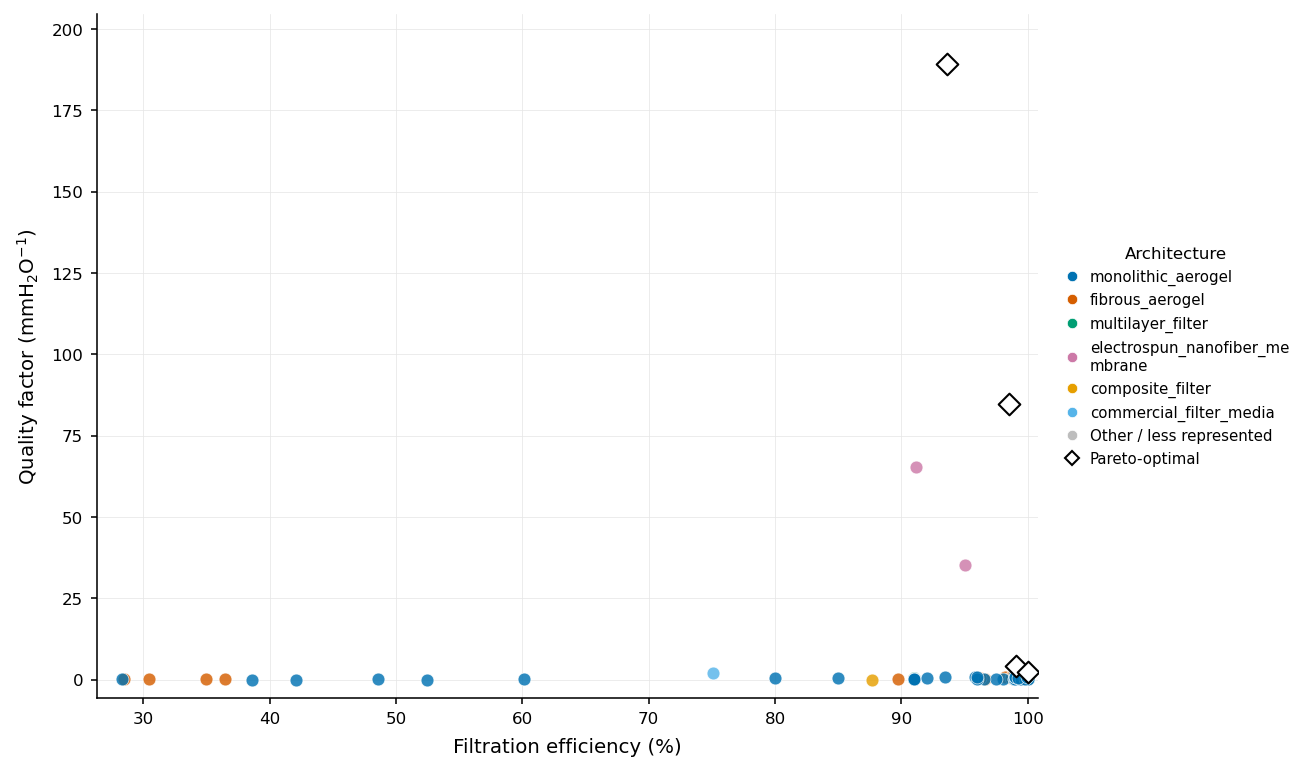

Saved: design_map_qf_journal.png / design_map_qf_journal.pdf
Pareto-optimal samples: 4


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from textwrap import fill

if QF_COL and EFF_COL:

    cols_qf = [EFF_COL, QF_COL]
    if ARCH_COL:
        cols_qf.append(ARCH_COL)

    qf_design = df_orig[cols_qf].copy()
    qf_design[EFF_COL] = pd.to_numeric(qf_design[EFF_COL], errors="coerce")
    qf_design[QF_COL] = pd.to_numeric(qf_design[QF_COL], errors="coerce")
    qf_design = qf_design.dropna(subset=[EFF_COL, QF_COL]).reset_index(drop=True)

    plt.rcParams.update({
        "font.size": 8.5,
        "font.family": "sans-serif",
        "axes.linewidth": 0.75,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.major.width": 0.75,
        "ytick.major.width": 0.75,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": 600,
    })


    if ARCH_COL and ARCH_COL in qf_design.columns:
        qf_design[ARCH_COL] = qf_design[ARCH_COL].fillna("Unknown").astype(str)

        top_n_arch = 7
        top_arch = qf_design[ARCH_COL].value_counts().head(top_n_arch).index.tolist()

        qf_design["_arch_plot"] = np.where(
            qf_design[ARCH_COL].isin(top_arch),
            qf_design[ARCH_COL],
            "Other / less represented"
        )

        base_colors = [
            "#0072B2",
            "#D55E00",
            "#009E73",
            "#CC79A7",
            "#E69F00",
            "#56B4E9",
            "#6A3D9A",
        ]

        arch_palette = {
            arch: base_colors[i % len(base_colors)]
            for i, arch in enumerate(top_arch)
        }
        arch_palette["Other / less represented"] = "#BDBDBD"

        arch_order = top_arch + ["Other / less represented"]

    else:
        qf_design["_arch_plot"] = "Samples"
        arch_palette = {"Samples": "#0072B2"}
        arch_order = ["Samples"]


    n = len(qf_design)
    qf_pareto = np.ones(n, dtype=bool)

    eff_vals = qf_design[EFF_COL].astype(float).values
    qf_vals = qf_design[QF_COL].astype(float).values

    for i in range(n):
        dominated = (
            (eff_vals >= eff_vals[i]) &
            (qf_vals >= qf_vals[i]) &
            ((eff_vals > eff_vals[i]) | (qf_vals > qf_vals[i]))
        )
        dominated[i] = False
        if dominated.any():
            qf_pareto[i] = False


    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.grid(
        True,
        which="major",
        linestyle="-",
        linewidth=0.35,
        color="#E6E6E6",
        zorder=0
    )

    for arch in arch_order[::-1]:
        sub = qf_design[qf_design["_arch_plot"] == arch]

        if sub.empty:
            continue

        is_other = arch == "Other / less represented"

        ax.scatter(
            sub[EFF_COL],
            sub[QF_COL],
            s=28 if is_other else 38,
            color=arch_palette[arch],
            alpha=0.38 if is_other else 0.82,
            edgecolors="white",
            linewidths=0.35,
            zorder=2 if is_other else 3,
            label=arch
        )

   
    pf2 = qf_design[qf_pareto].copy().sort_values(EFF_COL)

    ax.scatter(
        pf2[EFF_COL],
        pf2[QF_COL],
        s=54,
        marker="D",
        facecolors="white",
        edgecolors="black",
        linewidths=1.0,
        zorder=6,
        label="Pareto-optimal"
    )

 
    ax.set_xlabel("Filtration efficiency (%)", fontsize=9.5, labelpad=5)
    ax.set_ylabel("Quality factor (mmH$_2$O$^{-1}$)", fontsize=9.5, labelpad=5)

    eff_upper = qf_design[EFF_COL].max()
    eff_lower = qf_design[EFF_COL].min()

    ax.set_xlim(
        left=max(0, eff_lower - 2),
        right=max(100.8, eff_upper + 0.8)
    )

    qf_upper = qf_design[QF_COL].max()
    qf_lower = qf_design[QF_COL].min()

    ax.set_ylim(
        bottom=min(-0.03 * qf_upper, qf_lower - 0.03 * qf_upper),
        top=qf_upper * 1.08
    )

    ax.tick_params(axis="both", labelsize=8)


    handles = []

    for arch in arch_order:
        handles.append(
            mlines.Line2D(
                [],
                [],
                color=arch_palette[arch],
                marker="o",
                linestyle="None",
                markersize=5,
                markeredgecolor="white",
                markeredgewidth=0.35,
                label=fill(arch, 24)
            )
        )

    handles.append(
        mlines.Line2D(
            [],
            [],
            color="black",
            marker="D",
            markerfacecolor="white",
            markeredgecolor="black",
            linestyle="None",
            markersize=5,
            label="Pareto-optimal"
        )
    )

    ax.legend(
        handles=handles,
        title="Architecture",
        title_fontsize=8,
        fontsize=7.2,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0,
        handlelength=1.3,
        handletextpad=0.5
    )

    plt.tight_layout()
    plt.savefig("design_map_qf_journal.png", dpi=600, bbox_inches="tight", facecolor="white")
    plt.savefig("design_map_qf_journal.pdf", bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved: design_map_qf_journal.png / design_map_qf_journal.pdf")
    print(f"Pareto-optimal samples: {qf_pareto.sum()}")
